# SECOM — Rigorous ML + Deep Learning Study

### Objective
Predict semiconductor yield failures from the UCI SECOM process/sensor measurements while avoiding data leakage.

### Models
**Classical ML**
- Logistic Regression
- Extra Trees
- LightGBM
- LightGBM + SMOTEENN

**Deep Learning**
- MLP + weighted binary cross-entropy
- MLP + focal loss
- MLP + SMOTE

**Optional**
- Autoencoder anomaly detection

### Important methodology
- Official UCI data loaded directly.
- Test set is untouched until final evaluation.
- Statistical feature selection is fitted inside each CV fold.
- Imputation/scaling/resampling are fitted only on training data.
- Threshold is selected from out-of-fold training predictions.
- Validation/test sets retain the original rare-failure prevalence.



In [1]:
!pip install -q -U imbalanced-learn lightgbm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 68.0 MB/s eta 0:00:00


In [3]:
import io
import zipfile
import urllib.request
import warnings
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline as SkPipeline
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import ExtraTreesClassifier

from sklearn.metrics import (
    balanced_accuracy_score, roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score, confusion_matrix,
    classification_report
)
from sklearn.feature_selection import mutual_info_classif

from lightgbm import LGBMClassifier

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))
print("All imports successful.")

TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
All imports successful.


In [4]:
# 2A. Verify GPU availability
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("Visible GPUs:", gpus)

if gpus:
    print("✅ GPU detected. TensorFlow will use the Colab GPU (e.g. T4).")
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except Exception:
            pass
else:
    print("⚠️ No GPU detected. The notebook will still run, but neural-network training will use CPU.")

# Optional device placement confirmation:
print("Logical GPUs:", tf.config.list_logical_devices("GPU"))


TensorFlow version: 2.20.0
Visible GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ GPU detected. TensorFlow will use the Colab GPU (e.g. T4).
Logical GPUs: [LogicalDevice(name='/device:GPU:0', device_type='GPU')]


## 3. Load the official UCI SECOM dataset

SECOM contains 1,567 examples and 590 usable process/sensor variables. Labels are -1 for pass and +1 for fail. We convert them to 0/1.


In [6]:
URL = "https://archive.ics.uci.edu/static/public/179/secom.zip"

def load_secom():
    with urllib.request.urlopen(URL, timeout=60) as response:
        data = response.read()

    with zipfile.ZipFile(io.BytesIO(data)) as z:
        names = z.namelist()

        def locate(filename):
            matches = [n for n in names if n.lower().endswith(filename.lower())]
            if not matches:
                raise FileNotFoundError(
                    f"{filename} not found in official UCI archive."
                )
            return matches[0]

        data_file = locate("secom.data")
        label_file = locate("secom_labels.data")

        # Sensor data
        with z.open(data_file) as f:
            X = pd.read_csv(
                f,
                sep=r"\s+",
                header=None,
                engine="python"
            )

        # IMPORTANT:
        # The label file contains:
        #   label  date  time
        #
        # Therefore read THREE columns, not TWO.
        with z.open(label_file) as f:
            labels = pd.read_csv(
                f,
                sep=r"\s+",
                header=None,
                names=["label", "date", "time"],
                engine="python"
            )

    # Safety checks
    if X.shape[0] != labels.shape[0]:
        raise ValueError(
            f"Row mismatch: X has {X.shape[0]} rows, "
            f"labels have {labels.shape[0]} rows."
        )

    # Give the 590 sensor columns stable names
    X.columns = [f"Sensor_{i+1}" for i in range(X.shape[1])]

    # SECOM:
    # -1 = pass
    # +1 = fail
    y = (labels["label"].astype(int) == 1).astype(int)

    # Combine date + time for later temporal analysis
    timestamps = (
        labels["date"].astype(str).str.strip('"')
        + " "
        + labels["time"].astype(str).str.strip('"')
    )

    return X, y, timestamps

X, y, timestamps = load_secom()

print("X:", X.shape)
print("y:", y.shape)
print(y.value_counts().sort_index())
print(f"Failure rate: {y.mean():.2%}")

assert X.shape == (1567, 590)
assert len(y) == 1567
assert int(y.sum()) == 104


X: (1567, 590)
y: (1567,)
label
0    1463
1     104
Name: count, dtype: int64
Failure rate: 6.64%


Constant features: 116
Features >50% missing: 28
Total missing cells: 41951


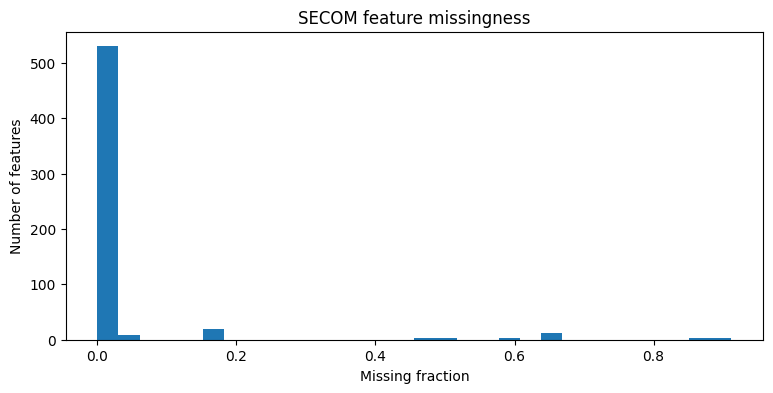

In [7]:
# 4. Data quality

missing_fraction = X.isna().mean()
constant_features = X.columns[X.nunique(dropna=True) <= 1].tolist()

print("Constant features:", len(constant_features))
print("Features >50% missing:", int((missing_fraction > 0.50).sum()))
print("Total missing cells:", int(X.isna().sum().sum()))

plt.figure(figsize=(9,4))
plt.hist(missing_fraction, bins=30)
plt.xlabel("Missing fraction")
plt.ylabel("Number of features")
plt.title("SECOM feature missingness")
plt.show()


## 5. Untouched stratified test set

All supervised decisions below use only `X_train, y_train`.

The final test set is used once at the end.


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)

print("Train:", X_train.shape, "failures:", int(y_train.sum()))
print("Test :", X_test.shape, "failures:", int(y_test.sum()))


Train: (1253, 590) failures: 83
Test : (314, 590) failures: 21


## 6. Leakage-free statistical selector

Mann–Whitney U + Benjamini–Hochberg FDR + robust effect size + rank AUC.

The selector is an sklearn estimator, so it is refitted independently inside every CV training fold.


In [9]:
class StatisticalFeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(
        self, missing_threshold=0.50, fdr_alpha=0.05,
        min_effect=0.15, max_features=80,
        corr_threshold=0.90, min_features=10
    ):
        self.missing_threshold = missing_threshold
        self.fdr_alpha = fdr_alpha
        self.min_effect = min_effect
        self.max_features = max_features
        self.corr_threshold = corr_threshold
        self.min_features = min_features

    @staticmethod
    def bh_adjust(p):
        p = np.asarray(p, dtype=float)
        n = len(p)
        order = np.argsort(p)
        ranked = p[order]
        q = ranked * n / np.arange(1, n + 1)
        q = np.minimum.accumulate(q[::-1])[::-1]
        out = np.empty(n)
        out[order] = np.clip(q, 0, 1)
        return out

    @staticmethod
    def rank_auc(a, b):
        n0, n1 = len(a), len(b)
        if n0 == 0 or n1 == 0:
            return 0.5
        vals = np.concatenate([a, b])
        ranks = pd.Series(vals).rank(method="average").to_numpy()
        u = ranks[n0:].sum() - n1 * (n1 + 1) / 2
        auc = u / (n0 * n1)
        return float(max(auc, 1 - auc))

    def fit(self, X, y):
        X = pd.DataFrame(X).copy()
        y = pd.Series(np.asarray(y)).reset_index(drop=True)
        X.reset_index(drop=True, inplace=True)

        self.feature_names_in_ = np.asarray(X.columns, dtype=object)

        # Remove constant features in this training fold.
        nonconstant = X.nunique(dropna=True) > 1
        candidates = X.columns[nonconstant].tolist()

        # Missingness filter.
        candidates = [
            c for c in candidates
            if X[c].isna().mean() <= self.missing_threshold
        ]

        if not candidates:
            raise ValueError("No features survived data-quality filtering.")

        Xi = X[candidates].replace([np.inf, -np.inf], np.nan)
        Xi = Xi.fillna(Xi.median()).fillna(0)

        neg = y.to_numpy() == 0
        pos = y.to_numpy() == 1

        rows = []
        for c in candidates:
            a = Xi.loc[neg, c].to_numpy()
            b = Xi.loc[pos, c].to_numpy()

            try:
                _, p = mannwhitneyu(a, b, alternative="two-sided")
                auc = self.rank_auc(a, b)
            except Exception:
                p, auc = 1.0, 0.5

            scale = np.nanstd(Xi[c].to_numpy(), ddof=1)
            effect = (
                abs(np.nanmedian(b) - np.nanmedian(a)) / scale
                if np.isfinite(scale) and scale > 1e-12 else 0.0
            )

            rows.append((c, p, effect, auc))

        stats = pd.DataFrame(rows, columns=["feature","p_value","effect","auc"])
        stats["q_value"] = self.bh_adjust(stats["p_value"])
        stats["auc_distance"] = (stats["auc"] - 0.5).abs()

        selected = stats[
            (stats.q_value <= self.fdr_alpha) &
            (stats.effect >= self.min_effect)
        ].copy()

        if len(selected) < self.min_features:
            selected = stats.sort_values(
                ["q_value","auc_distance","effect"],
                ascending=[True,False,False]
            ).head(min(self.max_features, len(stats)))

        selected = selected.sort_values(
            ["q_value","auc_distance","effect"],
            ascending=[True,False,False]
        ).head(self.max_features)

        names = selected.feature.tolist()

        # Redundancy pruning.
        if len(names) > 1:
            corr = Xi[names].corr(method="spearman").abs()
            kept = []
            for c in names:
                if all(corr.loc[c, k] < self.corr_threshold for k in kept):
                    kept.append(c)
            names = kept

        if not names:
            names = [stats.sort_values("q_value").iloc[0].feature]

        self.selected_features_ = names
        self.statistics_ = stats.sort_values("q_value").reset_index(drop=True)
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        return X[self.selected_features_].copy()

    def get_feature_names_out(self, input_features=None):
        return np.asarray(self.selected_features_, dtype=object)


## 7. Classical models

All preprocessing and resampling stay inside the pipeline.


In [11]:
def new_selector():
    return StatisticalFeatureSelector(
        missing_threshold=0.50,
        fdr_alpha=0.05,
        min_effect=0.15,
        max_features=80,
        corr_threshold=0.90,
        min_features=10
    )

def lgbm_model(weighted=False):
    params = dict(
        n_estimators=300,
        learning_rate=0.03,
        num_leaves=15,
        min_child_samples=20,
        subsample=0.85,
        colsample_bytree=0.80,
        reg_lambda=2.0,
        reg_alpha=0.1,
        objective="binary",
        random_state=SEED,
        n_jobs=-1,
        verbosity=-1
    )
    if weighted:
        params["scale_pos_weight"] = float((y_train==0).sum() / (y_train==1).sum())
    return LGBMClassifier(**params)

classical = {
    "Logistic_Weighted": Pipeline([
        ("selector", new_selector()),
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("scaler", RobustScaler()),
        ("model", LogisticRegression(
            max_iter=3000, class_weight="balanced",
            C=0.5, solver="liblinear", random_state=SEED
        ))
    ]),

    "ExtraTrees_None": Pipeline([
        ("selector", new_selector()),
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("model", ExtraTreesClassifier(
            n_estimators=500, min_samples_leaf=2,
            max_features="sqrt", class_weight="balanced",
            n_jobs=-1, random_state=SEED
        ))
    ]),

    "LightGBM_Weighted": Pipeline([
        ("selector", new_selector()),
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("model", lgbm_model(weighted=True))
    ]),

    "LightGBM_SMOTEENN": Pipeline([
        ("selector", new_selector()),
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("sampler", SMOTEENN(random_state=SEED)),
        ("model", lgbm_model(weighted=False))
    ])
}

print(*classical.keys(), sep="\n")

Logistic_Weighted
ExtraTrees_None
LightGBM_Weighted
LightGBM_SMOTEENN


## 8. Classical-model CV

We use the same 5 folds for all models. Validation prevalence remains natural.


In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def metric_row(name, y_true, prob, threshold=0.5):
    pred = (prob >= threshold).astype(int)
    return {
        "model": name,
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "roc_auc": roc_auc_score(y_true, prob),
        "pr_auc": average_precision_score(y_true, prob),
        "recall": recall_score(y_true, pred, zero_division=0),
        "precision": precision_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0)
    }

classical_oof = {}
classical_rows = []

for name, model in classical.items():
    print("Running:", name)
    prob = cross_val_predict(
        model, X_train, y_train,
        cv=cv, method="predict_proba", n_jobs=1
    )[:,1]
    classical_oof[name] = prob
    classical_rows.append(metric_row(name, y_train, prob, 0.5))

classical_results = pd.DataFrame(classical_rows)
display(classical_results.round(4))


Running: Logistic_Weighted
Running: ExtraTrees_None
Running: LightGBM_Weighted
Running: LightGBM_SMOTEENN


,model,balanced_accuracy,roc_auc,pr_auc,recall,precision,f1
0,Logistic_Weighted,0.6256,0.6287,0.1114,0.4940,0.1262,0.2010
1,ExtraTrees_None,0.4996,0.7142,0.1716,0.0000,0.0000,0.0000
2,LightGBM_Weighted,0.5259,0.6847,0.1593,0.0723,0.2000,0.1062
3,LightGBM_SMOTEENN,0.5806,0.6937,0.1555,0.2048,0.2500,0.2252


## 9. Deep-learning preprocessing

For the neural networks, feature selection is fitted once on the training data **only** to construct the neural feature space. This is not used to claim a nested neural CV estimate; the neural models are evaluated with repeated stratified holdout/CV below.

For strict benchmarking, the final test set remains untouched.


In [13]:
# Fit statistical selector only on training data for the neural experiments.
nn_selector = new_selector()
nn_selector.fit(X_train, y_train)

Xtr_sel = nn_selector.transform(X_train)
Xte_sel = nn_selector.transform(X_test)

nn_imputer = SimpleImputer(strategy="median", add_indicator=True)
Xtr_imp = nn_imputer.fit_transform(Xtr_sel)
Xte_imp = nn_imputer.transform(Xte_sel)

nn_scaler = RobustScaler()
Xtr = nn_scaler.fit_transform(Xtr_imp).astype("float32")
Xte = nn_scaler.transform(Xte_imp).astype("float32")

ytr = y_train.to_numpy().astype("float32")
yte = y_test.to_numpy().astype("float32")

print("Neural input shape:", Xtr.shape)
print("Selected sensors:", len(nn_selector.selected_features_))


Neural input shape: (1253, 109)
Selected sensors: 56


## 10. MLP definitions

In [14]:
def build_mlp(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.35),
        layers.Dense(64, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.30),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.20),
        layers.Dense(1, activation="sigmoid")
    ])
    return model

def focal_loss(alpha=0.75, gamma=2.0):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1-1e-7)
        pt = tf.where(tf.equal(y_true, 1.0), y_pred, 1-y_pred)
        alpha_t = tf.where(tf.equal(y_true, 1.0), alpha, 1-alpha)
        return tf.reduce_mean(-alpha_t * tf.pow(1-pt, gamma) *
                              (y_true*tf.math.log(y_pred) +
                               (1-y_true)*tf.math.log(1-y_pred)))
    return loss

def compile_mlp(loss):
    model = build_mlp(Xtr.shape[1])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=loss,
        metrics=[
            keras.metrics.AUC(name="roc_auc"),
            keras.metrics.AUC(curve="PR", name="pr_auc")
        ]
    )
    return model

neg_count = float((ytr == 0).sum())
pos_count = float((ytr == 1).sum())
total = neg_count + pos_count

class_weight = {
    0: total / (2 * neg_count),
    1: total / (2 * pos_count)
}

print("Class weights:", class_weight)


Class weights: {0: 0.5354700854700855, 1: 7.548192771084337}


In [16]:
# 11. Train MLP + weighted BCE

keras.backend.clear_session()
mlp_weighted = compile_mlp("binary_crossentropy")

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_pr_auc",
        mode="max",
        patience=25,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_pr_auc",
        mode="max",
        factor=0.5,
        patience=10,
        min_lr=1e-5
    )
]

hist_weighted = mlp_weighted.fit(
    Xtr, ytr,
    validation_split=0.20,
    epochs=200,
    batch_size=32,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=0
)

mlp_weighted_prob = mlp_weighted.predict(Xte, verbose=0).ravel()

print("Best validation PR-AUC:",
      max(hist_weighted.history["val_pr_auc"]))

Best validation PR-AUC: 0.1807534545660019


In [18]:
# 12. Train MLP + focal loss

keras.backend.clear_session()
mlp_focal = compile_mlp(focal_loss(alpha=0.75, gamma=2.0))

hist_focal = mlp_focal.fit(
    Xtr, ytr,
    validation_split=0.20,
    epochs=200,
    batch_size=32,
    callbacks=callbacks,
    verbose=0
)

mlp_focal_prob = mlp_focal.predict(Xte, verbose=0).ravel()

print("Best validation PR-AUC:",
      max(hist_focal.history["val_pr_auc"]))

Best validation PR-AUC: 0.1558728814125061


In [19]:
# 13. Train MLP + SMOTE

sm = SMOTE(random_state=SEED)
Xtr_sm, ytr_sm = sm.fit_resample(Xtr, ytr)

print("Before SMOTE:", np.bincount(ytr.astype(int)))
print("After SMOTE :", np.bincount(ytr_sm.astype(int)))

keras.backend.clear_session()
mlp_smote = compile_mlp("binary_crossentropy")

hist_smote = mlp_smote.fit(
    Xtr_sm, ytr_sm,
    validation_split=0.20,
    epochs=200,
    batch_size=32,
    callbacks=callbacks,
    verbose=0
)

mlp_smote_prob = mlp_smote.predict(Xte, verbose=0).ravel()


Before SMOTE: [1170   83]
After SMOTE : [1170 1170]


## 14. Neural-network threshold selection

The neural networks use the validation portion of the training data to choose a threshold. The untouched test set is not used to choose it.

Because the dataset is tiny, neural results should be treated as a comparison rather than a definitive claim of superiority.


In [20]:
# Create a fixed stratified validation split for threshold selection.
X_fit, X_val, y_fit, y_val = train_test_split(
    Xtr, ytr, test_size=0.20, stratify=ytr, random_state=SEED
)

def best_threshold(y_true, prob):
    grid = np.linspace(0.02, 0.80, 157)
    rows = []
    for t in grid:
        pred = (prob >= t).astype(int)
        rows.append((
            t,
            balanced_accuracy_score(y_true, pred),
            recall_score(y_true, pred, zero_division=0),
            precision_score(y_true, pred, zero_division=0),
            f1_score(y_true, pred, zero_division=0)
        ))
    df = pd.DataFrame(rows, columns=["threshold","ba","recall","precision","f1"])
    row = df.sort_values(["ba","recall","precision"], ascending=False).iloc[0]
    return float(row.threshold)

# Use the validation split to select thresholds by retraining each model
# on X_fit and evaluating X_val.
def train_nn_for_validation(loss, use_smote=False, weighted=False):
    keras.backend.clear_session()
    model = compile_mlp(loss)

    Xf, yf = X_fit, y_fit
    cw = class_weight if weighted else None

    if use_smote:
        Xf, yf = SMOTE(random_state=SEED).fit_resample(Xf, yf)

    model.fit(
        Xf, yf,
        validation_data=(X_val, y_val),
        epochs=200,
        batch_size=32,
        class_weight=cw,
        callbacks=callbacks,
        verbose=0
    )
    p = model.predict(X_val, verbose=0).ravel()
    return model, p

val_models = {}

val_models["MLP_WeightedBCE"], p = train_nn_for_validation(
    "binary_crossentropy", weighted=True
)
val_models["MLP_WeightedBCE_threshold"] = best_threshold(y_val, p)

val_models["MLP_Focal"], p = train_nn_for_validation(
    focal_loss(alpha=0.75, gamma=2.0)
)
val_models["MLP_Focal_threshold"] = best_threshold(y_val, p)

val_models["MLP_SMOTE"], p = train_nn_for_validation(
    "binary_crossentropy", use_smote=True
)
val_models["MLP_SMOTE_threshold"] = best_threshold(y_val, p)

print("Neural thresholds:")
print("Weighted BCE:", val_models["MLP_WeightedBCE_threshold"])
print("Focal loss  :", val_models["MLP_Focal_threshold"])
print("SMOTE       :", val_models["MLP_SMOTE_threshold"])


Neural thresholds:
Weighted BCE: 0.5
Focal loss  : 0.42500000000000004
SMOTE       : 0.5750000000000001


## 15. Final neural models

For the final test evaluation, each neural architecture is retrained on all training data using its previously selected validation threshold.

This keeps test data out of threshold selection.


In [21]:
# Retrain final neural models on all training data.

def fit_final_nn(loss, weighted=False, use_smote=False):
    keras.backend.clear_session()
    model = compile_mlp(loss)

    Xf, yf = Xtr, ytr
    cw = class_weight if weighted else None

    if use_smote:
        Xf, yf = SMOTE(random_state=SEED).fit_resample(Xf, yf)

    model.fit(
        Xf, yf,
        validation_split=0.20,
        epochs=200,
        batch_size=32,
        class_weight=cw,
        callbacks=callbacks,
        verbose=0
    )
    return model

final_mlp_weighted = fit_final_nn("binary_crossentropy", weighted=True)
final_mlp_focal = fit_final_nn(focal_loss(alpha=0.75, gamma=2.0))
final_mlp_smote = fit_final_nn("binary_crossentropy", use_smote=True)

nn_test_probs = {
    "MLP_WeightedBCE": final_mlp_weighted.predict(Xte, verbose=0).ravel(),
    "MLP_Focal": final_mlp_focal.predict(Xte, verbose=0).ravel(),
    "MLP_SMOTE": final_mlp_smote.predict(Xte, verbose=0).ravel()
}

nn_thresholds = {
    "MLP_WeightedBCE": val_models["MLP_WeightedBCE_threshold"],
    "MLP_Focal": val_models["MLP_Focal_threshold"],
    "MLP_SMOTE": val_models["MLP_SMOTE_threshold"]
}

nn_rows = [
    metric_row(name, y_test, prob, nn_thresholds[name])
    for name, prob in nn_test_probs.items()
]

nn_results = pd.DataFrame(nn_rows)
display(nn_results.round(4))


,model,balanced_accuracy,roc_auc,pr_auc,recall,precision,f1
0,MLP_WeightedBCE,0.4876,0.4175,0.0805,0.2857,0.0619,0.1017
1,MLP_Focal,0.5721,0.6184,0.1076,0.7619,0.0812,0.1468
2,MLP_SMOTE,0.4966,0.7455,0.1783,0.0000,0.0000,0.0000


## 16. Optional autoencoder anomaly detection

The autoencoder is deliberately kept separate from the supervised classifiers.

A useful experiment is to train it on **training-pass examples only**. It learns a representation of normal process behavior. Reconstruction error becomes an anomaly score.

This is not a replacement for supervised failure prediction.


In [22]:
# 16. Autoencoder trained on PASS examples only

X_normal = Xtr[ytr == 0]

keras.backend.clear_session()

latent_dim = min(16, max(4, Xtr.shape[1] // 8))

encoder_input = keras.Input(shape=(Xtr.shape[1],))
x = layers.Dense(128, activation="relu")(encoder_input)
x = layers.Dropout(0.20)(x)
x = layers.Dense(64, activation="relu")(x)
latent = layers.Dense(latent_dim, activation="linear")(x)

x = layers.Dense(64, activation="relu")(latent)
x = layers.Dense(128, activation="relu")(x)
decoder_output = layers.Dense(Xtr.shape[1], activation="linear")(x)

autoencoder = keras.Model(encoder_input, decoder_output)
autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse"
)

ae_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        patience=8,
        factor=0.5,
        min_lr=1e-5
    )
]

autoencoder.fit(
    X_normal, X_normal,
    validation_split=0.20,
    epochs=200,
    batch_size=32,
    callbacks=ae_callbacks,
    verbose=0
)

train_normal_recon = autoencoder.predict(X_normal, verbose=0)
test_recon = autoencoder.predict(Xte, verbose=0)

normal_error = np.mean((X_normal - train_normal_recon)**2, axis=1)
test_error = np.mean((Xte - test_recon)**2, axis=1)

print("Normal reconstruction error median:", np.median(normal_error))
print("Test reconstruction error median:", np.median(test_error))

ae_auc = roc_auc_score(yte, test_error)
ae_pr = average_precision_score(yte, test_error)

print("Autoencoder ROC-AUC:", round(ae_auc, 4))
print("Autoencoder PR-AUC :", round(ae_pr, 4))


Normal reconstruction error median: 0.7069227
Test reconstruction error median: 0.6503749
Autoencoder ROC-AUC: 0.7156
Autoencoder PR-AUC : 0.1925


In [23]:
# 17. Autoencoder threshold from normal training data only

# Conservative anomaly threshold: high percentile of normal reconstruction error.
ae_threshold = np.percentile(normal_error, 95)
ae_pred = (test_error >= ae_threshold).astype(int)

ae_row = metric_row(
    "Autoencoder_95th_percentile",
    y_test,
    test_error,
    ae_threshold
)

display(pd.DataFrame([ae_row]).round(4))

print("AE confusion matrix:")
print(confusion_matrix(y_test, ae_pred))


,model,balanced_accuracy,roc_auc,pr_auc,recall,precision,f1
0,Autoencoder_95th_percentile,0.5696,0.7156,0.1925,0.1905,0.2105,0.2


AE confusion matrix:
[[278  15]
 [ 17   4]]


## 18. Final model comparison

Important: neural-network test scores can be noisy on this tiny dataset. The untouched test set contains only a small number of failures.

The comparison should therefore be interpreted together with CV/validation stability rather than as a race for the largest single number.


In [24]:
# Combine classical and neural test results.

# Fit each classical model on the complete training set and evaluate once.
classical_test_rows = []

for name, model in classical.items():
    print("Final fitting:", name)
    model.fit(X_train, y_train)
    prob = model.predict_proba(X_test)[:,1]

    # OOF threshold selected from training data.
    oof_prob = classical_oof[name]
    threshold = best_threshold(y_train, oof_prob)

    row = metric_row(name, y_test, prob, threshold)
    row["threshold"] = threshold
    classical_test_rows.append(row)

classical_test_results = pd.DataFrame(classical_test_rows)

neural_test_results = nn_results.copy()
neural_test_results["threshold"] = neural_test_results["model"].map(nn_thresholds)

ae_final = pd.DataFrame([ae_row])
ae_final["threshold"] = ae_threshold

all_test_results = pd.concat(
    [classical_test_results, neural_test_results, ae_final],
    ignore_index=True
)

display(
    all_test_results[
        ["model","threshold","balanced_accuracy","roc_auc",
         "pr_auc","recall","precision","f1"]
    ].sort_values(
        ["pr_auc","balanced_accuracy"],
        ascending=False
    ).round(4)
)


Final fitting: Logistic_Weighted
Final fitting: ExtraTrees_None
Final fitting: LightGBM_Weighted
Final fitting: LightGBM_SMOTEENN


,model,threshold,balanced_accuracy,roc_auc,pr_auc,recall,precision,f1
1,ExtraTrees_None,0.1350,0.7530,0.8059,0.2718,0.7619,0.1758,0.2857
2,LightGBM_Weighted,0.0300,0.6696,0.7554,0.2400,0.6190,0.1368,0.2241
3,LightGBM_SMOTEENN,0.0400,0.6490,0.7281,0.2284,0.6667,0.1148,0.1958
7,Autoencoder_95th_percentile,7.7621,0.5696,0.7156,0.1925,0.1905,0.2105,0.2000
6,MLP_SMOTE,0.5750,0.4966,0.7455,0.1783,0.0000,0.0000,0.0000
0,Logistic_Weighted,0.4450,0.6271,0.6504,0.1322,0.5238,0.1222,0.1982
5,MLP_Focal,0.4250,0.5721,0.6184,0.1076,0.7619,0.0812,0.1468
4,MLP_WeightedBCE,0.5000,0.4876,0.4175,0.0805,0.2857,0.0619,0.1017


## 20. Statistical candidate signals

These are candidate process variables for engineering investigation.

Because SECOM variables are anonymized, do **not** assign physical names such as pressure, temperature, flow, etc. without external documentation.


In [ ]:
final_selector = new_selector()
final_selector.fit(X_train, y_train)

selected_stats = final_selector.statistics_[
    final_selector.statistics_.feature.isin(final_selector.selected_features_)
].copy()

print("Selected candidate signals:", len(final_selector.selected_features_))
display(selected_stats.round(5))


# 21. Conclusion

- Built a leakage-controlled semiconductor yield-failure screening pipeline.
- Addressed severe class imbalance.
- Compared classical ML and neural approaches.
- Used statistical feature screening and redundancy reduction.
- Used OOF/validation threshold selection.
- Evaluated an autoencoder as a separate anomaly-detection approach.

**The model identifies statistical signals associated with yield failures; those signals are candidates for process-engineering investigation and validation.**
